In [1]:
import warnings;
warnings.simplefilter('ignore')
from dcr import *

In [2]:
%matplotlib inline
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (16,9)
plt.rcParams.update({'font.size': 16})

In [3]:
from dcr import *  

data,data_train, data_test, _, _, _, _ = dataprep(data, depvar='lgd_time', splitvar='time',  threshold=40) 

data_default = data.loc[data['default_time'] == 1,:].copy()  

data_default.loc[data_default['lgd_time'] <= 0, 'lgd_time'] = 0.0001  
data_default.loc[data_default['lgd_time'] >= 1, 'lgd_time'] = 0.9999  

data_default = resolutionbias(data_default, 'lgd_time', 'res_time', 'time').reset_index(drop=False) 

In [4]:
model_ols = smf.ols(formula='lgd_time ~ cep_time + equity_time + interest_rate_time + FICO_orig_time + REtype_CO_orig_time + REtype_PU_orig_time + gdp_time', data=data_default).fit() 
print(model_ols.summary()) 

                            OLS Regression Results                            
Dep. Variable:               lgd_time   R-squared:                       0.094
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                     22.59
Date:                Sun, 17 Aug 2025   Prob (F-statistic):           2.92e-29
Time:                        12:26:29   Log-Likelihood:                -146.29
No. Observations:                1524   AIC:                             308.6
Df Residuals:                    1516   BIC:                             351.2
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.4674    

In [5]:
model_ols2 = smf.ols(formula='lgd_time ~ cep_time + equity_time + interest_rate_time +  FICO_orig_time + REtype_CO_orig_time + REtype_PU_orig_time + gdp_time + state_orig_time', data=data_default).fit() 

In [6]:
fittedvalues = pd.DataFrame(model_ols2.fittedvalues,columns = ['lgd_time_fit']) 
data_default2 = pd.merge(data_default, fittedvalues, right_index=True, left_index=True)

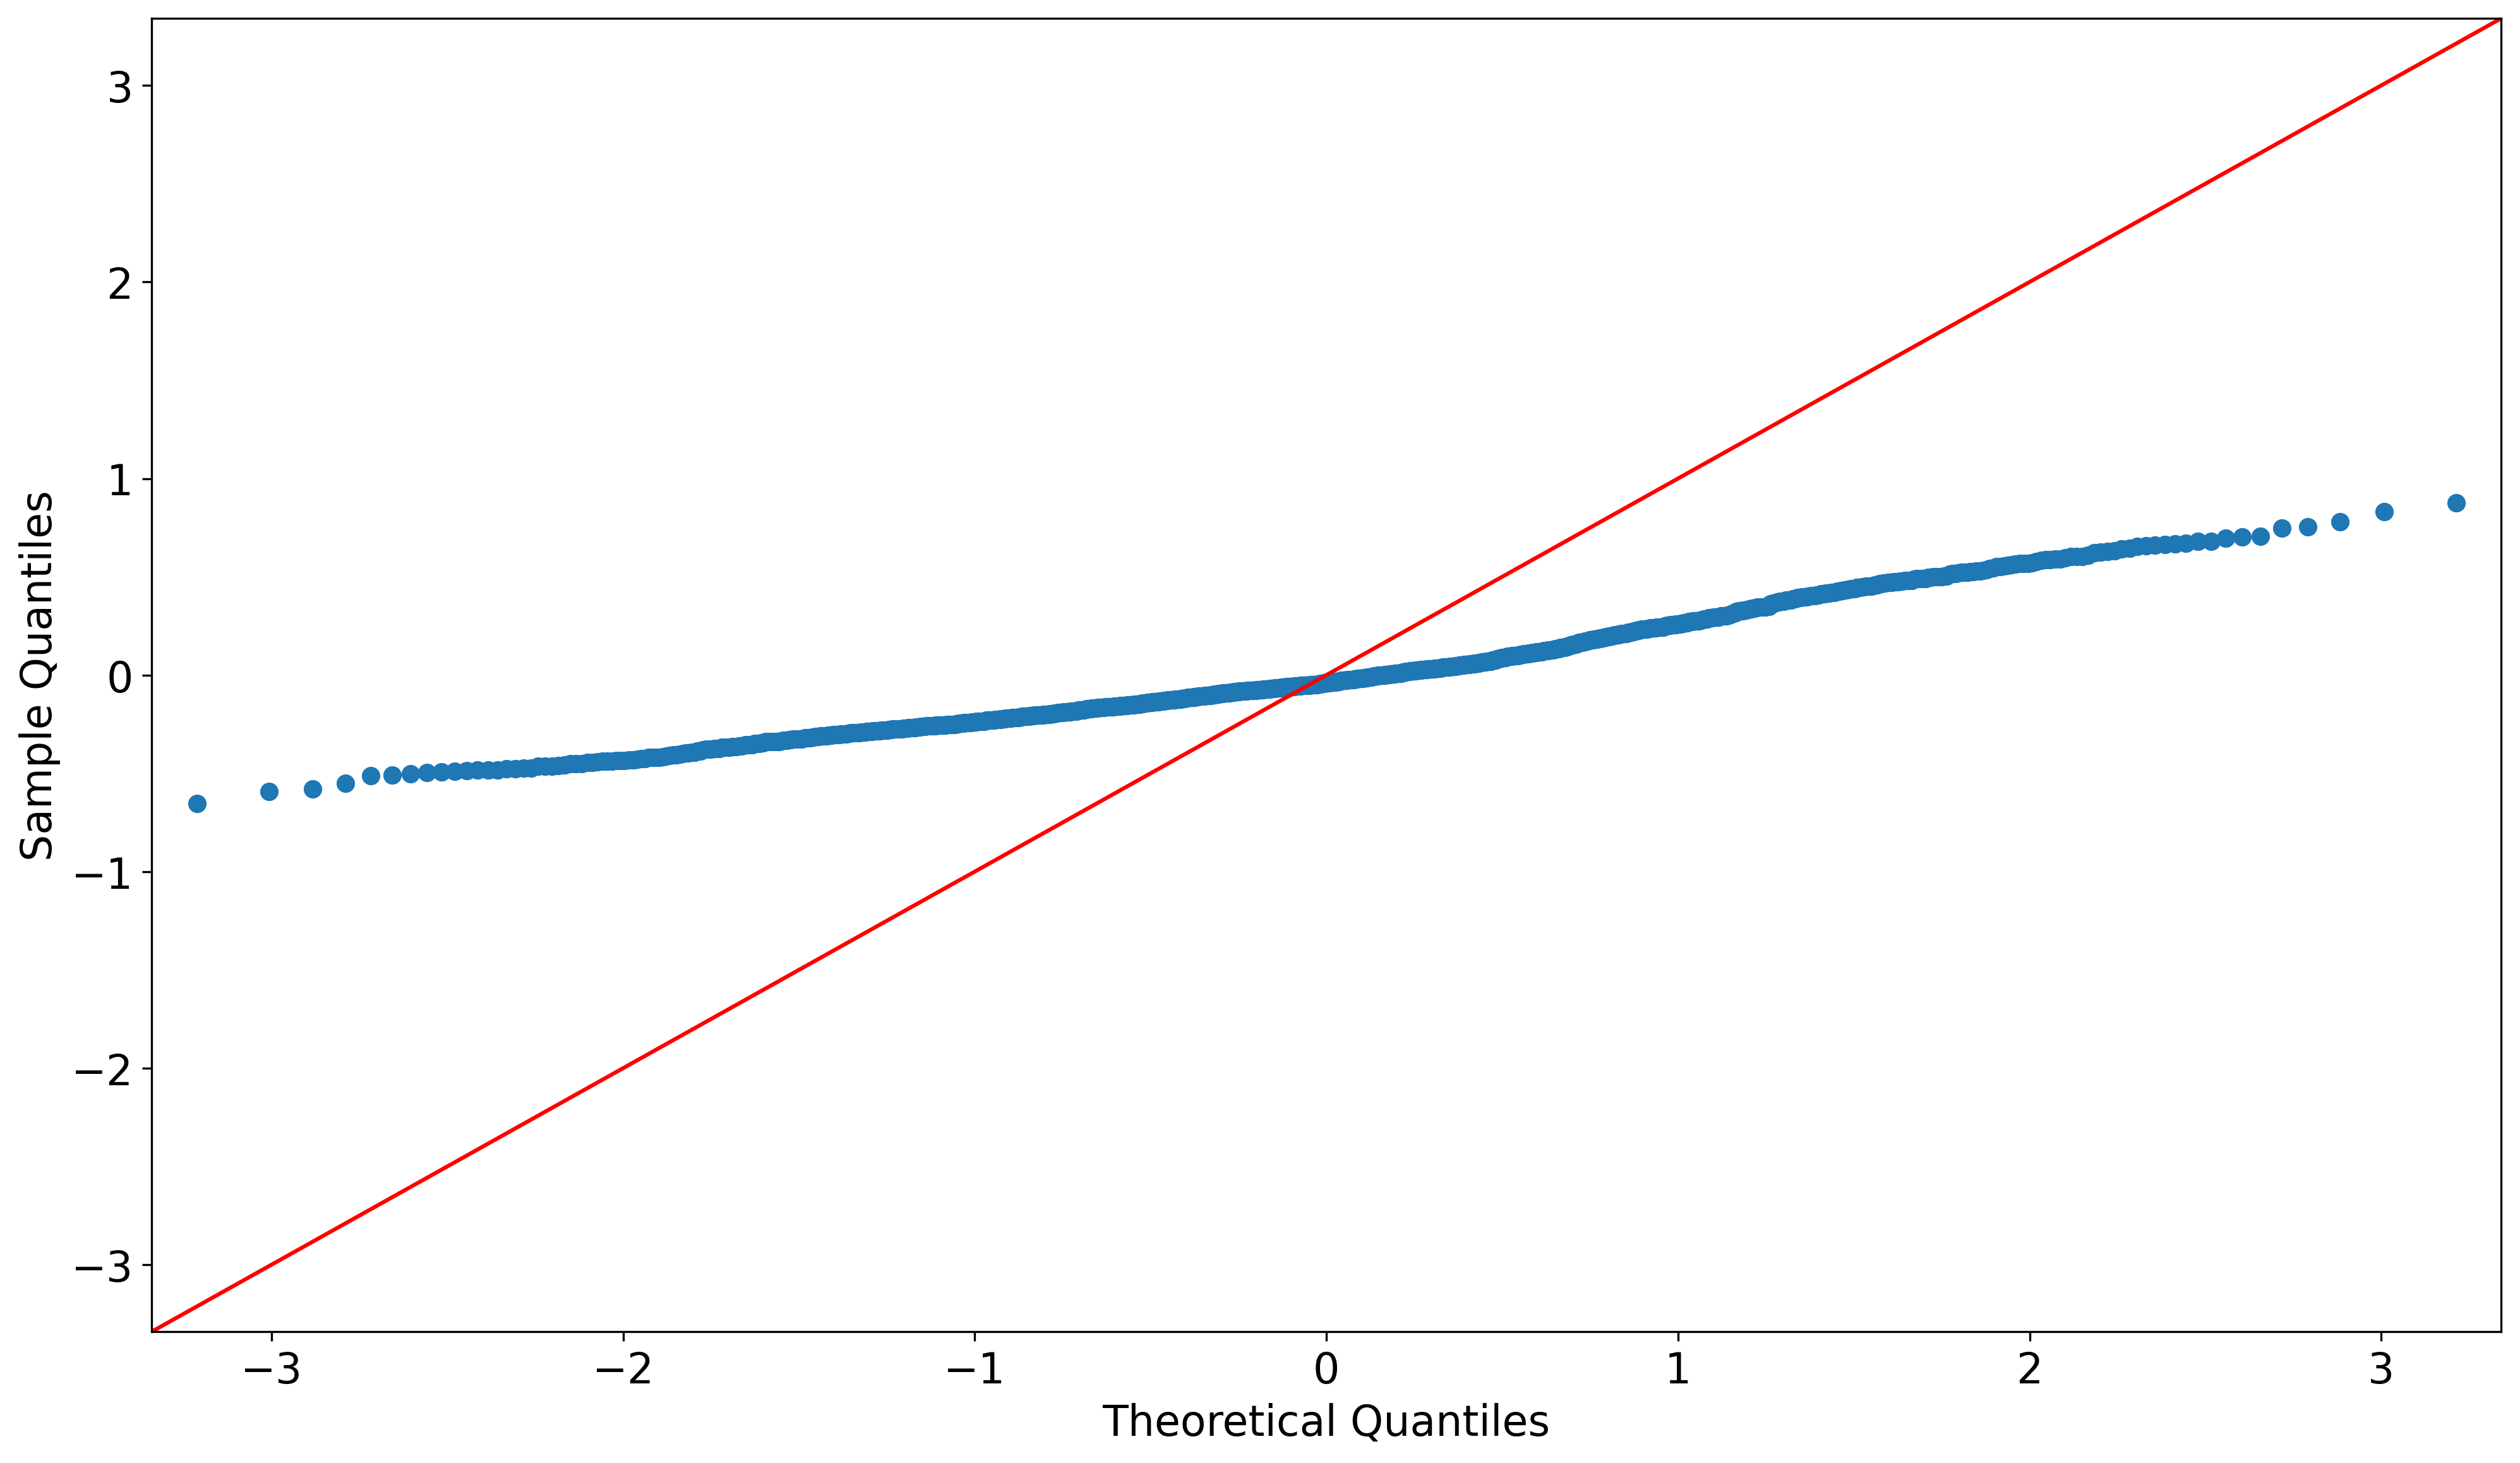

Shapiro-Wilk p-value: 0.0


In [7]:
data_default2.loc[:,'residuals'] = (data_default2.lgd_time_fit - data_default2.lgd_time)  
sm.qqplot(data_default2.residuals, line='45')  
pylab.show()  
stat, p = shapiro(data_default2.residuals)  
print('Shapiro-Wilk p-value:', round(p,4)) 

In [8]:
data_default2.loc[data_default2['lgd_time_fit'] <= 0, 'lgd_time_fit'] = 0.0001
data_default2.loc[data_default2['lgd_time_fit'] >= 1, 'lgd_time_fit'] = 0.9999 

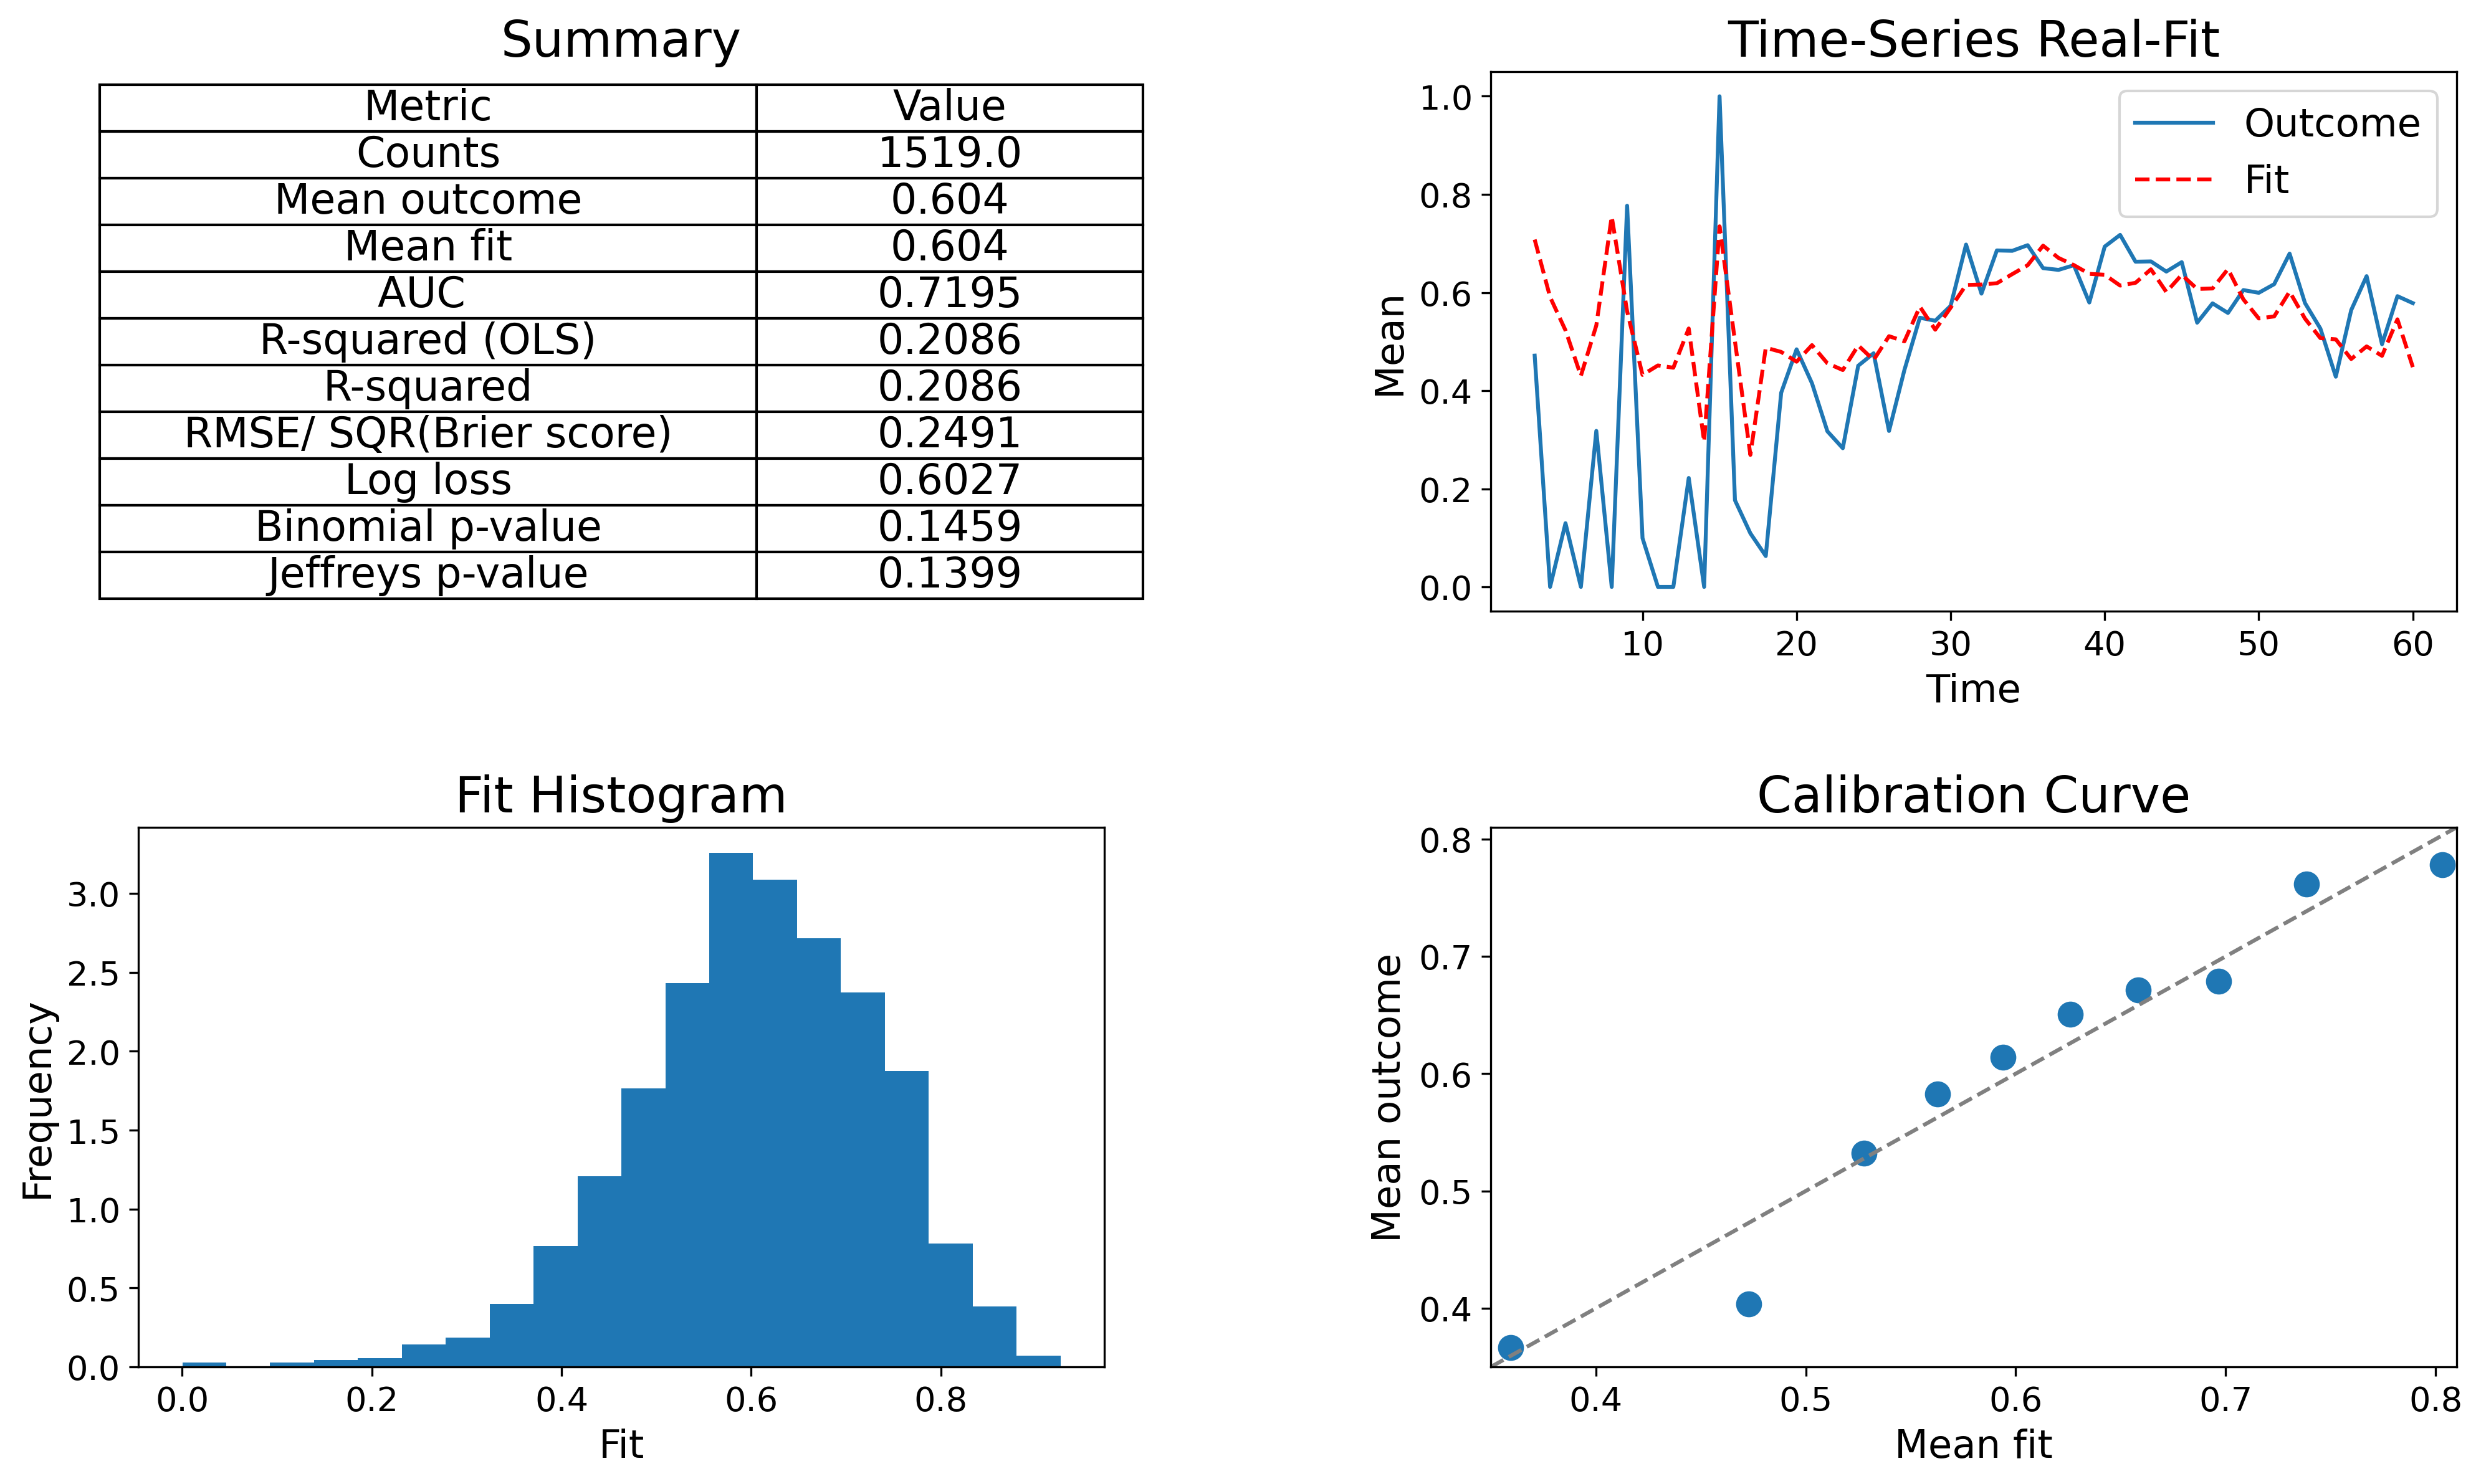

In [9]:
validation(data_default2.lgd_time_fit, data_default2.lgd_time, data_default2.time,  continuous=True) 

In [10]:
data_default.loc[:,'lgd_time_t'] = log(data_default.loc[:,'lgd_time']/ (1-data_default.loc  [:,'lgd_time'])) 
model_ols_t = smf.ols(formula='lgd_time_t ~ cep_time + equity_time + interest_rate_time +  FICO_orig_time + REtype_CO_orig_time + REtype_PU_orig_time + gdp_time + state_orig_time', data=data_default).fit()

In [11]:
fittedvalues = pd.DataFrame(model_ols_t.fittedvalues, columns = ['lgd_time_t_fit'])  
data_default2 = pd.merge(data_default, fittedvalues, right_index=True, left_index=True)  
print(data_default2[['lgd_time_t','lgd_time_t_fit']].describe().round(decimals=2)) 

       lgd_time_t  lgd_time_t_fit
count     1519.00         1519.00
mean         0.58            0.58
std          3.79            1.61
min         -9.21           -9.21
25%         -0.23           -0.37
50%          0.78            0.59
75%          1.09            1.62
max          9.21            5.02


In [12]:
data_default2.loc[:,'lgd_time_fit'] = 1/ (1+exp(-data_default2.lgd_time_t_fit))

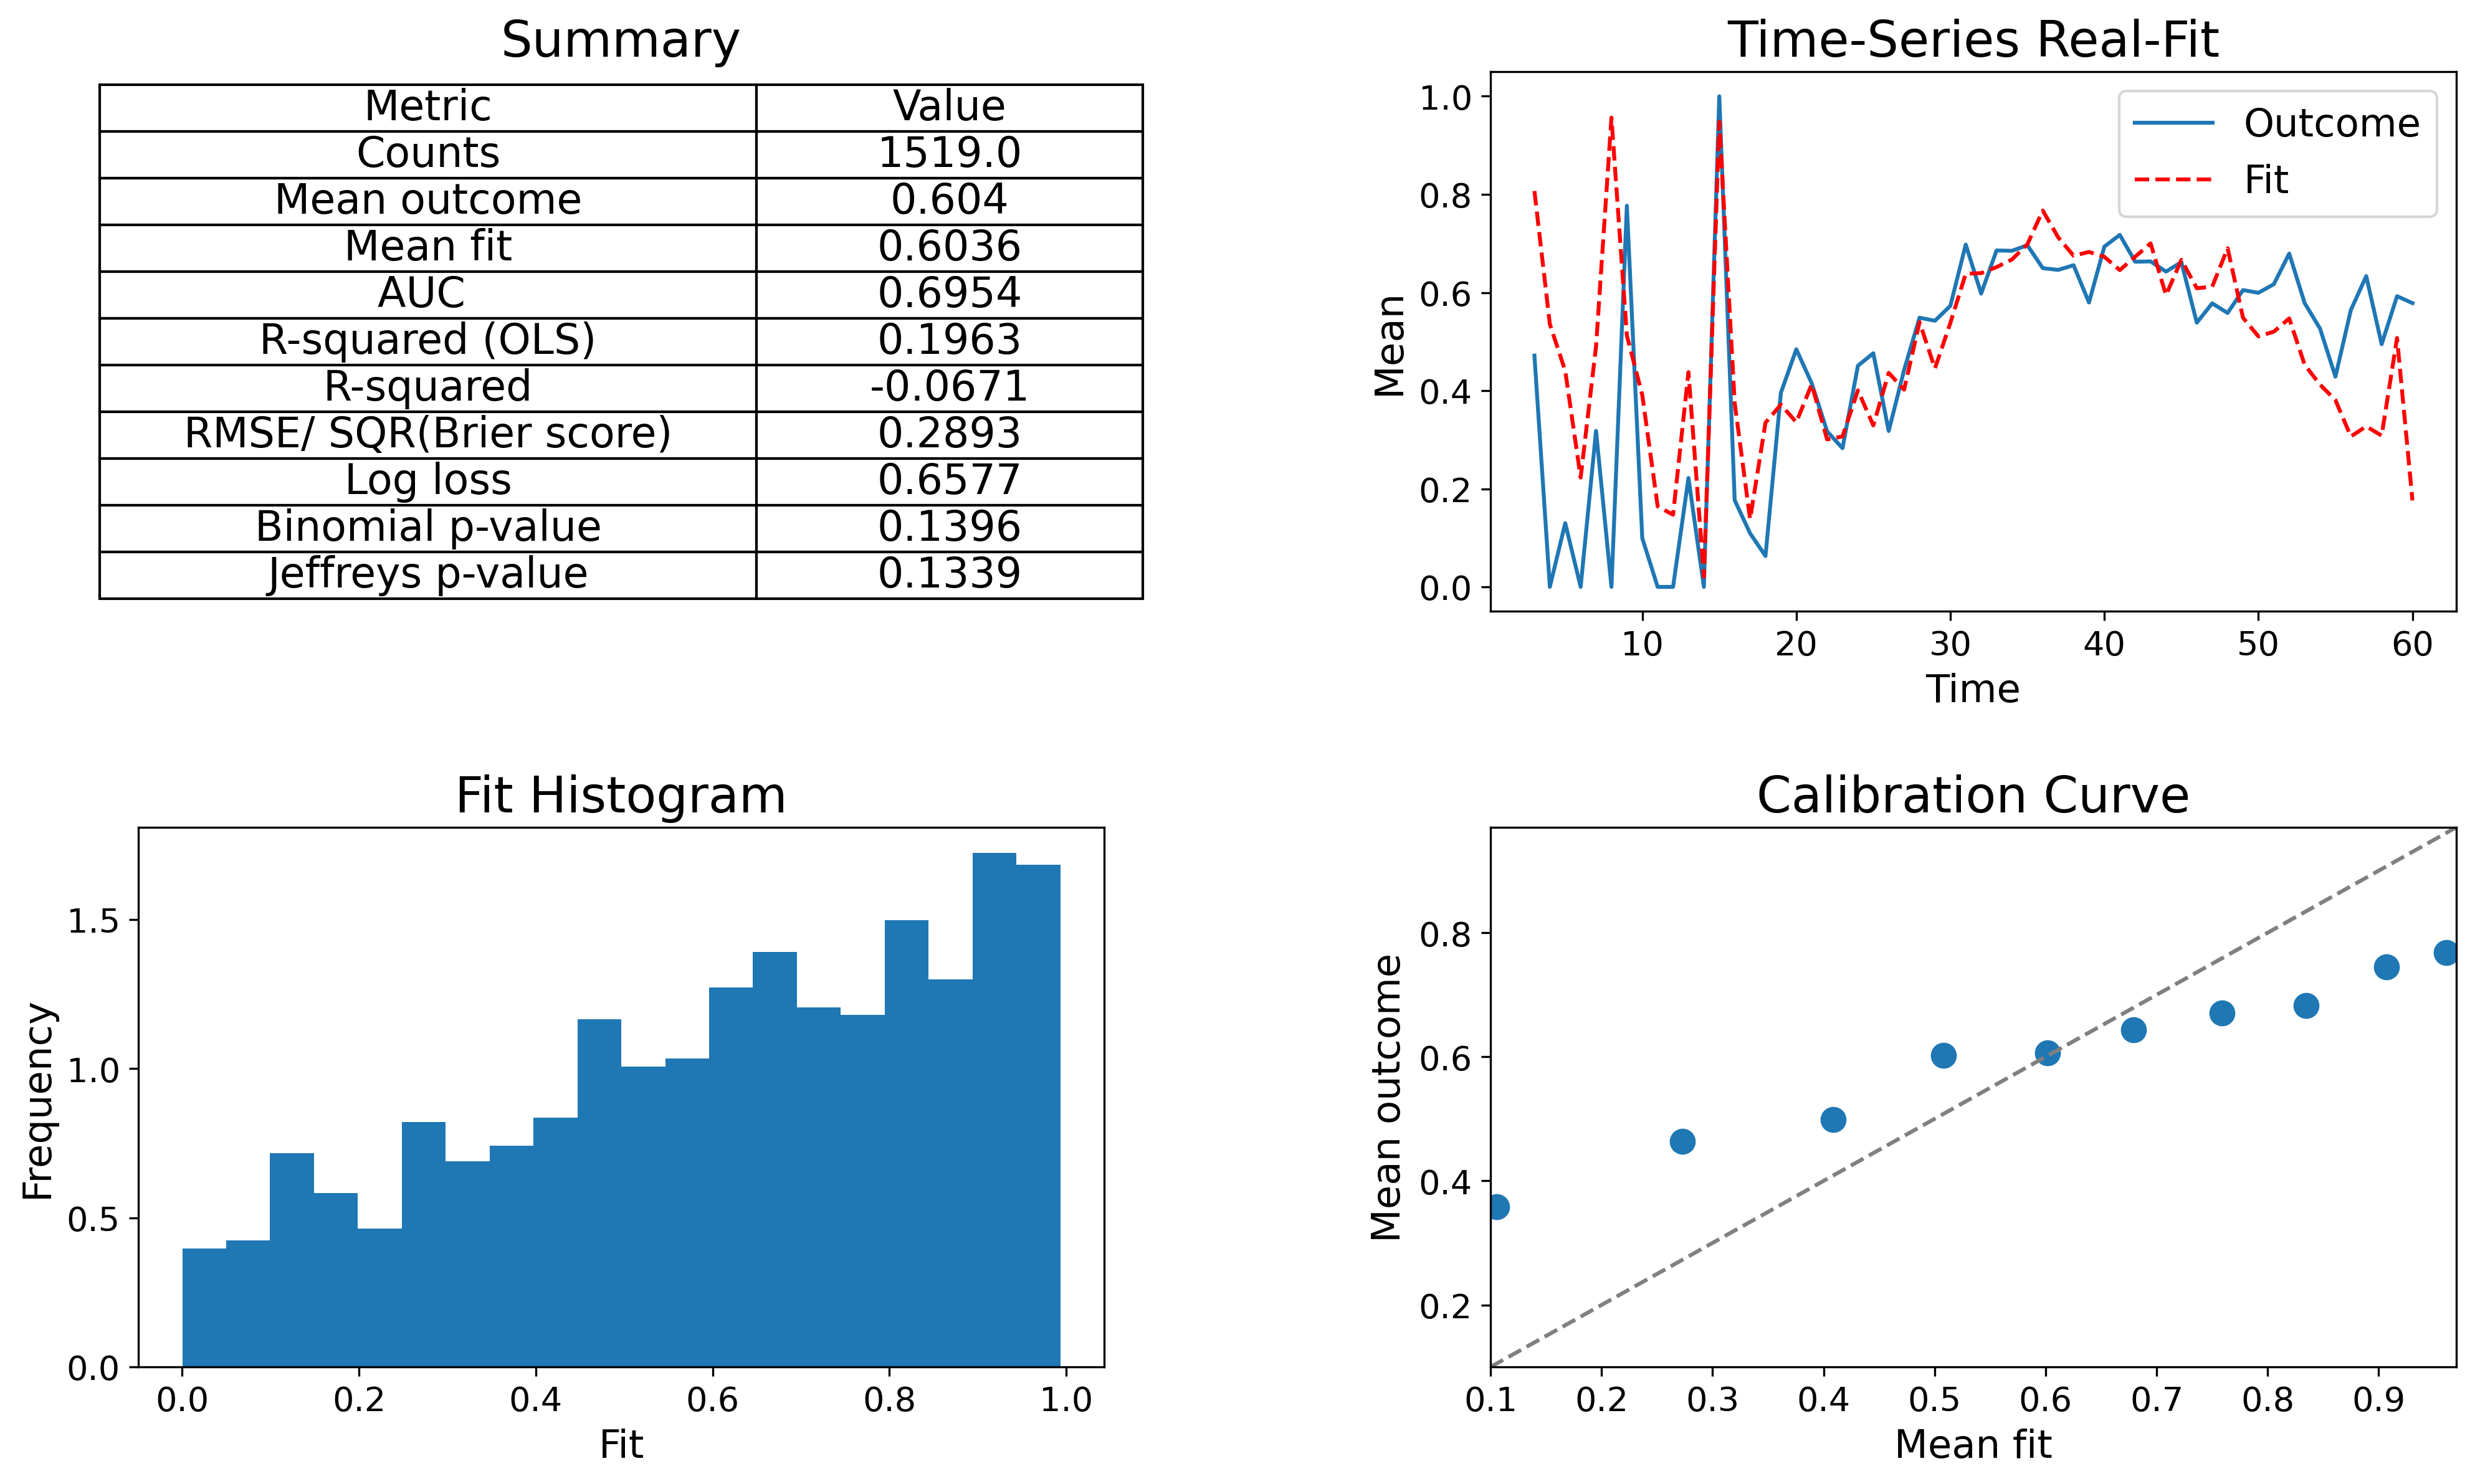

In [13]:
validation(data_default2.lgd_time_fit, data_default2.lgd_time, data_default2.time,  continuous=True)

In [14]:
data_default['constant'] = 1  
data_default2 = data_default[['lgd_time', 'constant', 'cep_time', 'equity_time', 'interest_rate_time', 'FICO_orig_time', 'REtype_CO_orig_time', 'REtype_PU_orig_time', 'gdp_time', 'state_orig_time']].dropna() 

y = data_default2[['lgd_time']] 
X = data_default2[['constant', 'cep_time', 'equity_time', 'interest_rate_time', 'FICO_orig_time', 'REtype_CO_orig_time', 'REtype_PU_orig_time', 'gdp_time', 'state_orig_time']]  
X = pd.get_dummies(X, columns=['state_orig_time'], prefix = ['state'])

In [24]:
def _ll_nonlinreg(y, X, beta):  
    xb = X.dot(beta) 
    mu = 1 / (1 + np.exp(-xb))  
    lh = (mu**y) * ((1 - mu)**(1 - y))  
    return np.log(lh + 1e-12)

class MyML(GenericLikelihoodModel): 
    def __init__(self, endog, exog, **kwds):  
        super(MyML, self).__init__(endog, exog, **kwds)  

    def nloglikeobs(self, params):  
        beta = params  
        ll = _ll_nonlinreg(self.endog, self.exog, beta)  
        return -ll

    def fit(self, start_params=None, maxiter=10000, maxfun=10000, **kwds):  
        if start_params is None:  
            start_params = np.zeros(self.exog.shape[1]) 
        return super(MyML, self).fit(start_params=start_params, 
                                     maxiter=maxiter, 
                                     maxfun=maxfun, 
                                     **kwds)  
    

y = np.asarray(y).ravel().astype(float)

X = np.asarray(X, dtype=float)
if X.ndim == 1:
    X = X.reshape(-1, 1)

print(y.dtype, X.dtype)
print(y.shape, X.shape)

model_fr = MyML(y,X).fit()

float64 float64
(1519,) (1519, 58)


In [25]:
print('Parameter estimates:', model_fr.params.round(decimals=4))

Parameter estimates: [ 8.200e-03  2.610e-02 -3.063e-01  5.360e-02  1.000e-04 -9.100e-02
 -1.808e-01 -7.150e-02  2.210e-02 -1.626e-01 -6.870e-02 -2.454e-01
  3.000e-02  2.850e-02  2.100e-03  1.272e-01 -2.440e-02  8.780e-02
 -1.789e-01  4.881e-01  3.920e-02 -3.070e-02  1.004e-01  4.662e-01
  9.690e-02 -5.690e-02  1.334e-01 -3.840e-02  1.857e-01 -7.860e-02
 -3.020e-02 -2.000e-02 -7.500e-01 -4.000e-02  9.800e-02  1.524e-01
 -7.500e-03 -9.780e-02  1.990e-02 -1.390e-02 -2.030e-02  4.130e-02
  7.200e-02  3.358e-01  5.810e-02 -2.100e-01 -3.750e-02 -2.513e-01
  2.824e-01  5.550e-02  3.270e-02 -4.320e-02  4.150e-02  2.700e-03
  1.990e-02 -1.306e-01  2.610e-02  2.760e-02]


In [26]:
fittedvalues = pd.DataFrame(1/(1+exp(-(X.dot(model_fr.params)))), columns = ['lgd_time_fit']) 
data_default2 = pd.merge(data_default, fittedvalues, right_index=True, left_index=True)

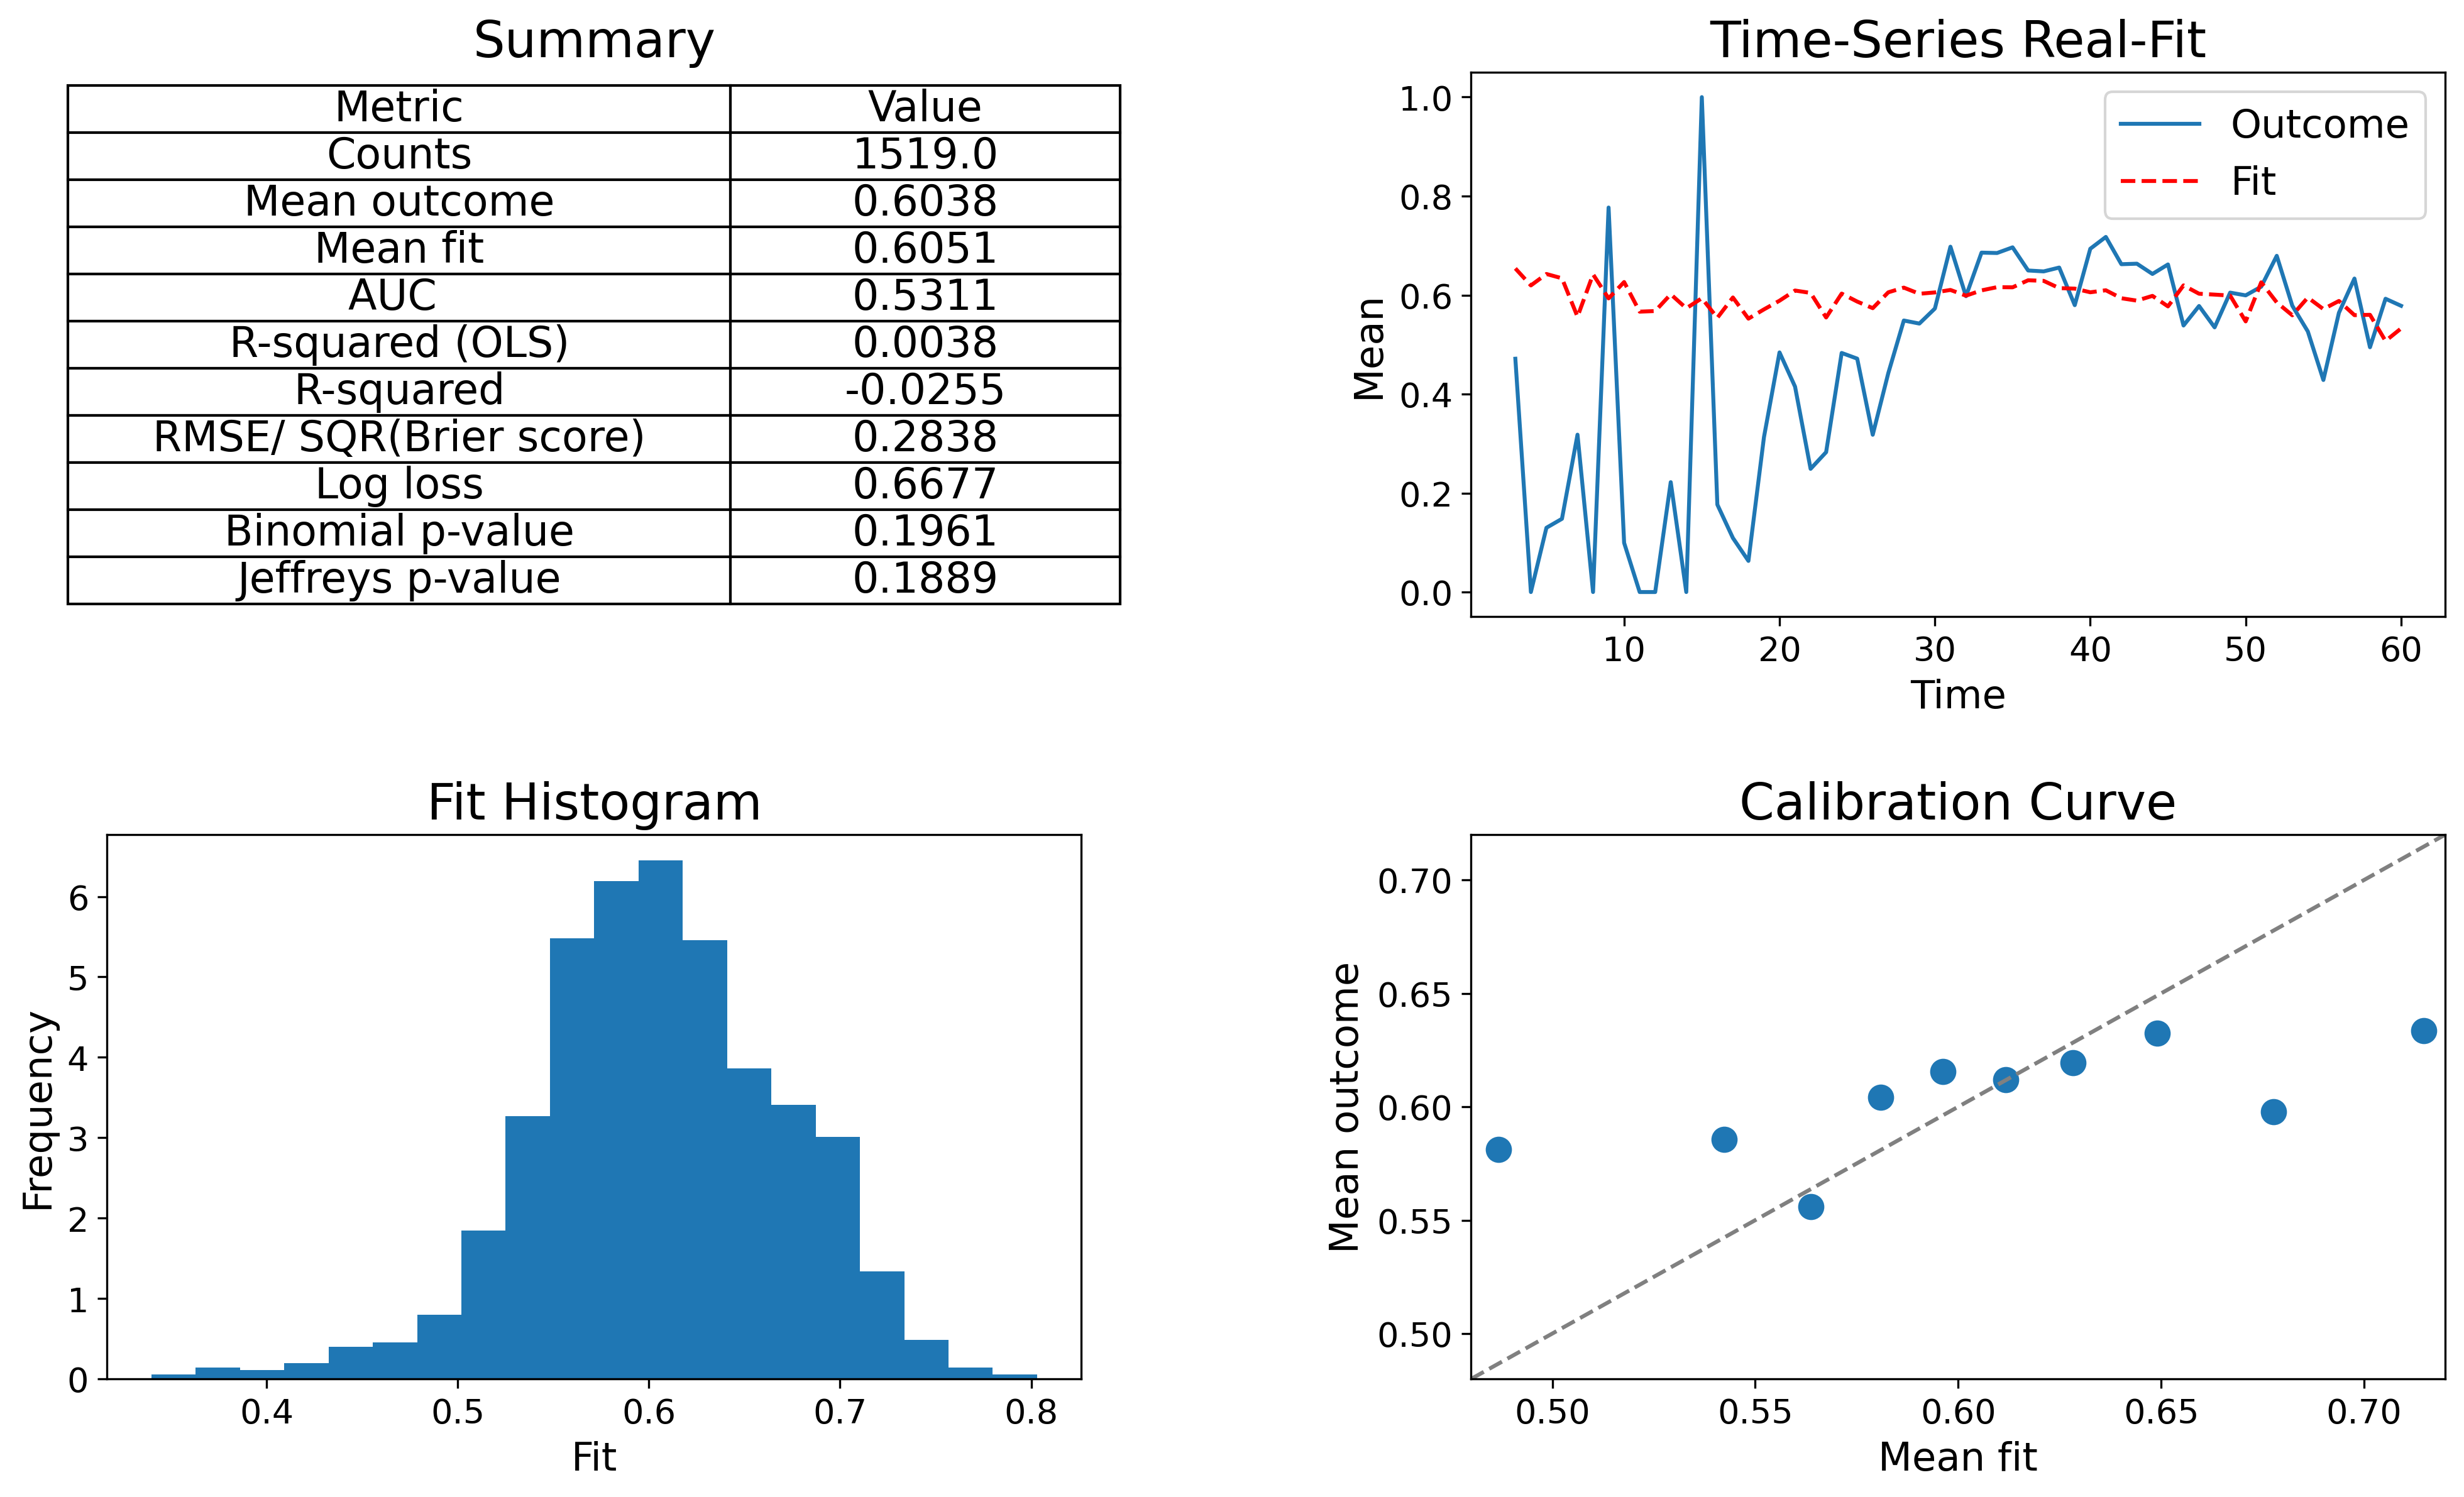

In [27]:
validation(data_default2.lgd_time_fit, data_default2.lgd_time, data_default2.time,  continuous=True) 

In [33]:
from scipy.special import gammaln

def _ll_nonlinreg(y, X, beta, cvec):  
    xb = X.dot(beta) 
    wc = X.dot(cvec) 
    
    mu = 1 / (1 + exp(-xb))  
    delta = exp(wc) 
    
    alpha = mu * delta  
    beta_dist = (1 - mu) * delta
    log_B = gammaln(alpha) + gammaln(beta_dist) - gammaln(alpha + beta_dist)

    log_lh = -log_B + (alpha - 1) * log(y) + (beta_dist - 1) * log(1 - y)
    
    return log_lh

class MyML(GenericLikelihoodModel):  
    def __init__(self, endog, exog, **kwds): 
        super(MyML, self).__init__(endog, exog, **kwds)  
        self.k_exog = exog.shape[1]

    def nloglikeobs(self, params): 
        beta = params[:self.k_exog]  
        cvec = params[self.k_exog:2*self.k_exog]  
        ll = _ll_nonlinreg(self.endog, self.exog, beta, cvec)  
        return -ll  

    def fit(self, start_params=None, maxiter=50000, maxfun=10000, **kwds): 
        if start_params is None:  
            start_params = np.zeros(2 * self.k_exog)  
        return super(MyML, self).fit(start_params=start_params,
                                     maxiter=maxiter,
                                     maxfun=maxfun,
                                     **kwds)


y = np.asarray(y).ravel().astype(float)
X = np.asarray(X, dtype=float)

if X.ndim == 1:
    X = X.reshape(-1, 1)

print(y.dtype, X.dtype)
print(y.shape, X.shape)

model_beta = MyML(y, X).fit()
print(model_beta.summary())

float64 float64
(1519,) (1519, 58)
                                 MyML Results                                 
Dep. Variable:                      y   Log-Likelihood:                 634.96
Model:                           MyML   AIC:                            -1156.
Method:            Maximum Likelihood   BIC:                            -852.3
Date:                Sun, 17 Aug 2025                                         
Time:                        14:30:22                                         
No. Observations:                1519                                         
Df Residuals:                    1462                                         
Df Model:                          56                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0045        nan        nan        nan         nan         nan
x1            -0.

In [34]:
print('Parameter estimates:', model_beta.params.round(decimals=4))

Parameter estimates: [ 4.500e-03 -3.380e-02  2.550e-02  1.520e-02  2.000e-04 -2.050e-02
  7.900e-03 -3.340e-02 -4.100e-03 -1.150e-02  9.200e-03 -1.540e-02
 -5.740e-02  5.460e-02 -4.610e-02 -4.700e-03  6.200e-03  2.250e-02
 -8.260e-02  2.000e-04  7.700e-03  1.110e-02 -2.950e-02 -7.700e-03
  3.300e-03 -1.019e-01  1.420e-02  2.060e-02  1.950e-02  3.600e-03
  1.940e-02 -7.700e-03 -7.300e-03  6.930e-02  6.240e-02  1.300e-03
 -3.500e-03  2.130e-02 -1.820e-02 -4.200e-03  3.660e-02 -1.290e-02
  4.800e-03  3.540e-02  2.660e-02  3.550e-02  1.590e-02  1.130e-02
 -1.700e-02  5.400e-03  1.690e-02 -4.000e-04 -6.100e-03 -1.900e-03
  1.580e-02  4.600e-03  2.510e-02  1.330e-02  1.850e-02  1.000e-04
  2.290e-02 -8.320e-02  1.100e-03 -6.430e-02  1.310e-02 -9.610e-02
  1.190e-02  2.710e-02 -1.300e-03 -5.500e-03  2.400e-03 -1.460e-02
  0.000e+00 -8.100e-03  3.650e-02  1.080e-02  5.800e-03  1.200e-03
 -2.800e-03  2.310e-02 -3.700e-03  4.450e-02  1.100e-02  1.000e-03
  2.450e-02 -5.700e-03  1.940e-02  1.140e

In [36]:
fittedvalues = pd.DataFrame(data=1/(1+exp(-(X.dot(model_beta.params[0:58])))), columns = ['lgd_time_fit']) 
data_default2 = pd.merge(data_default, fittedvalues, right_index=True, left_index=True)

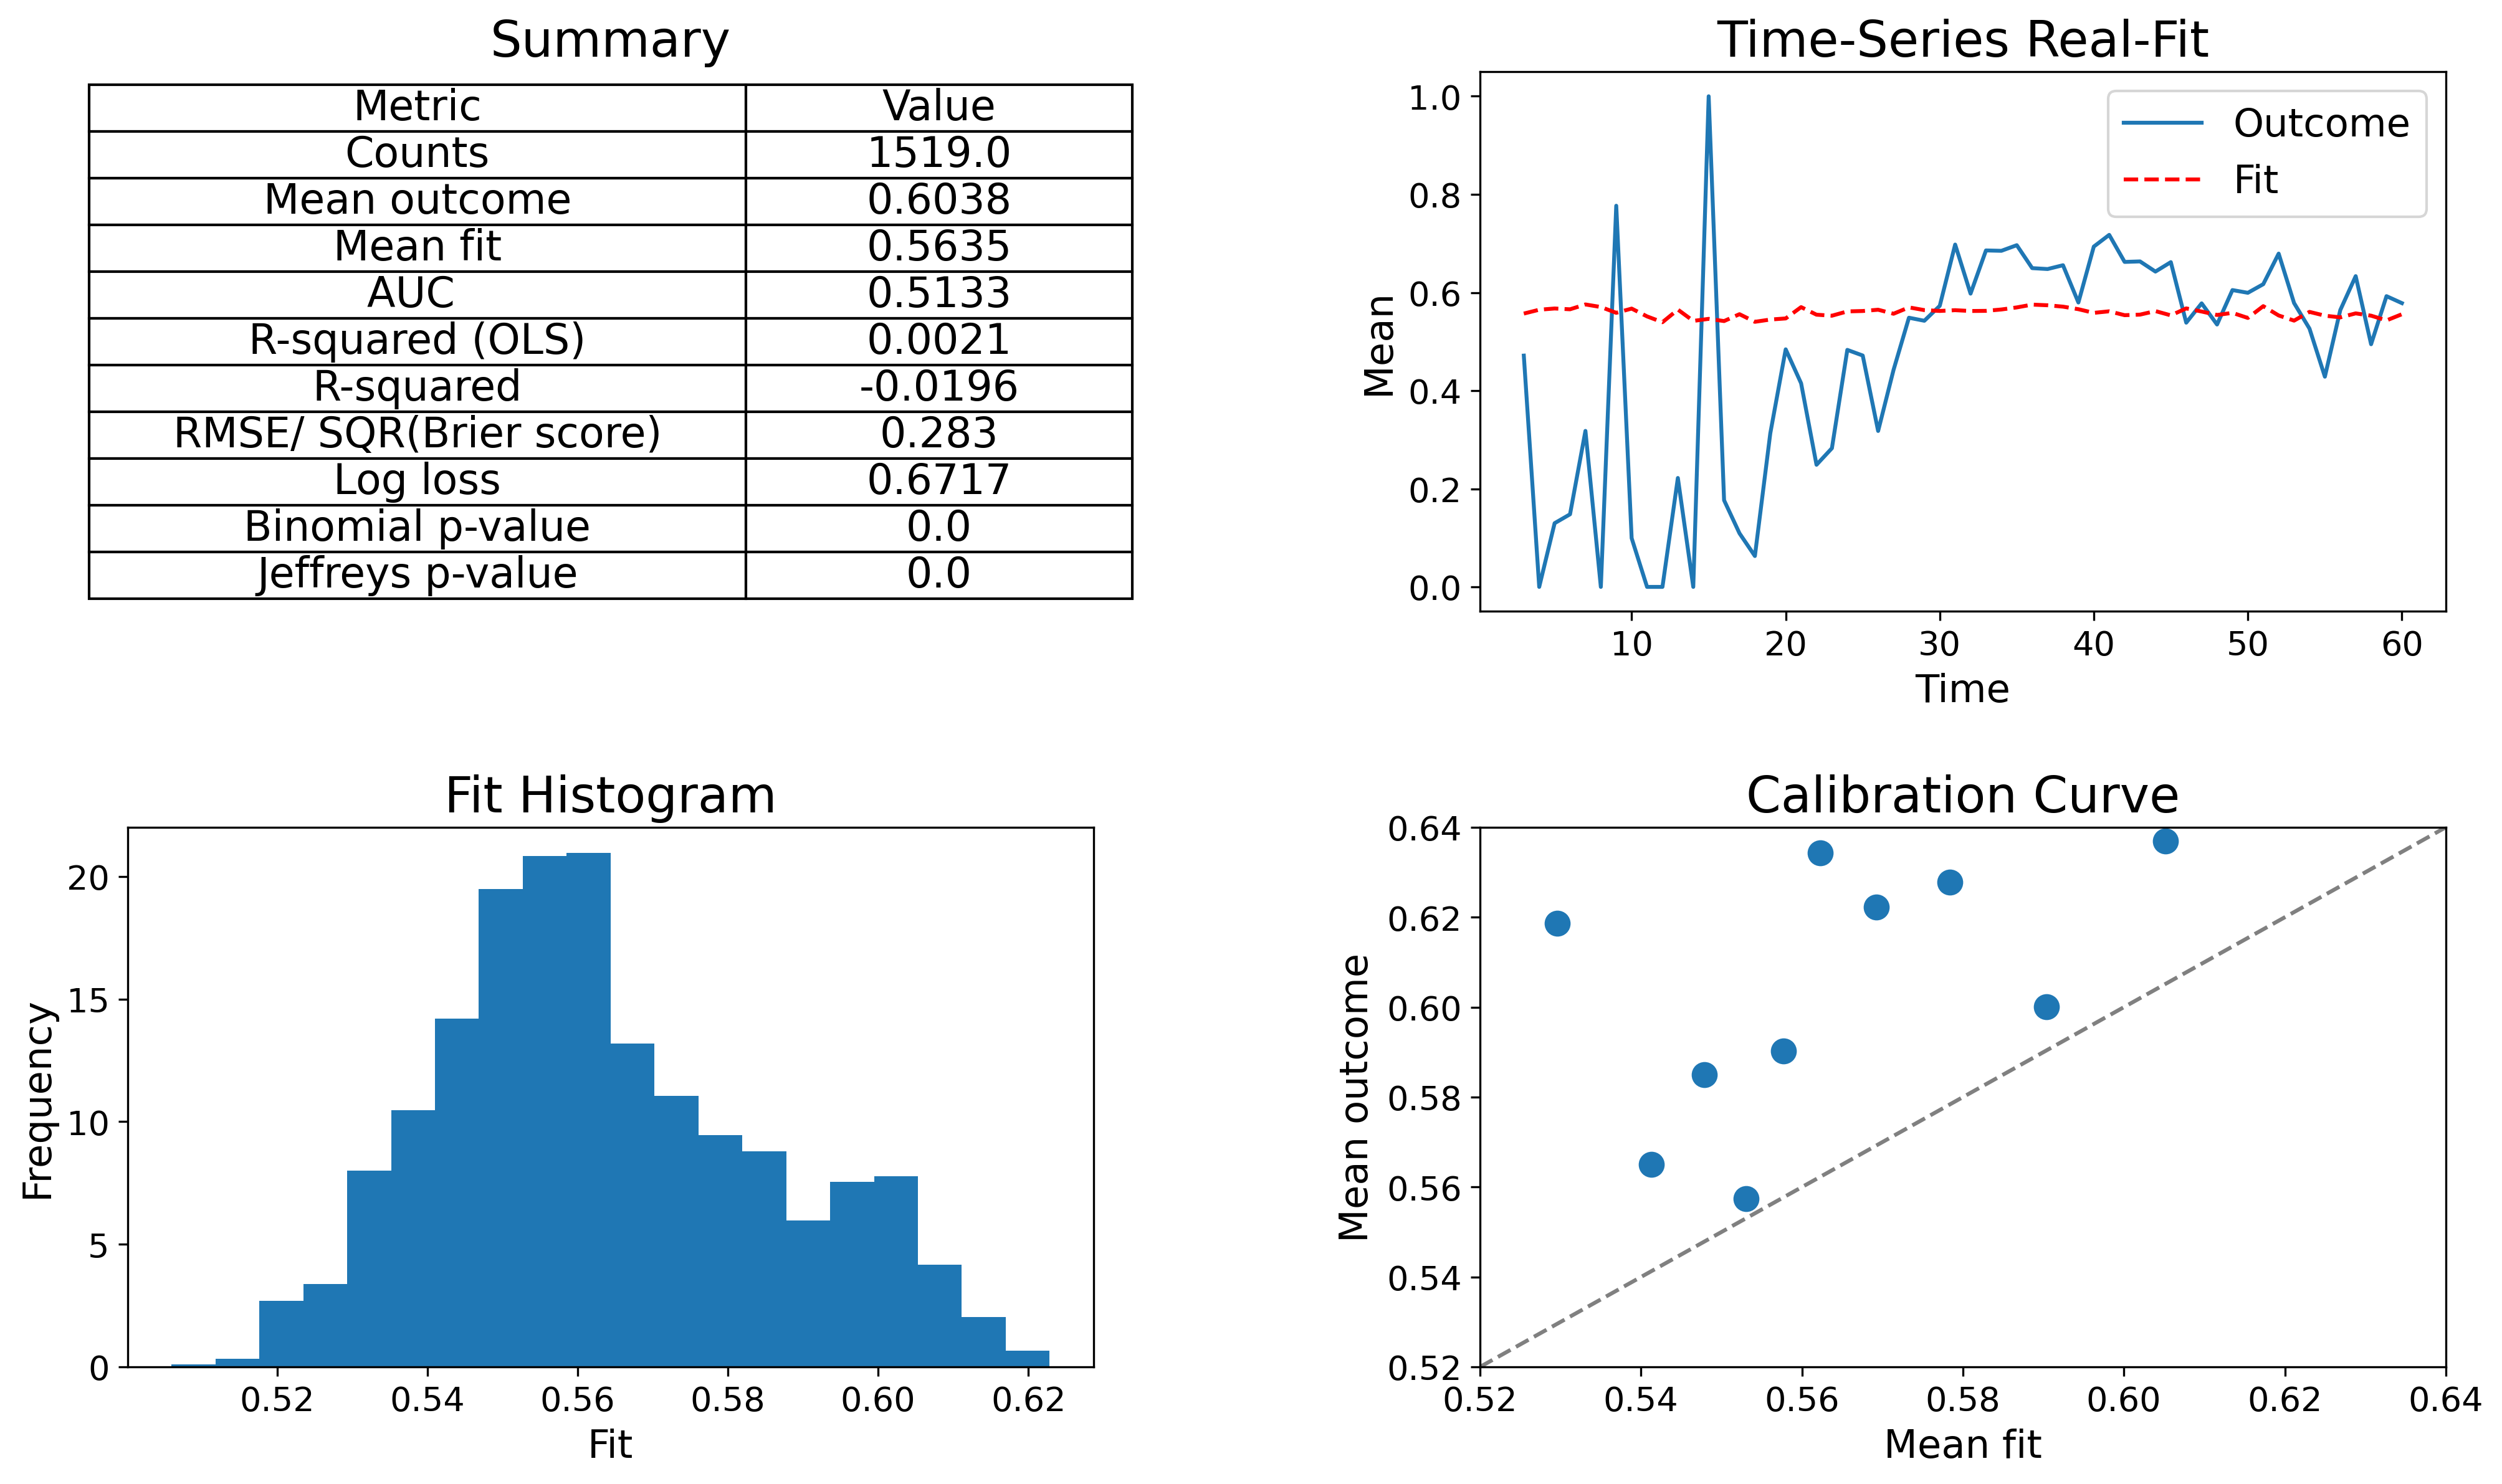

In [37]:
validation(data_default2.lgd_time_fit, data_default2.lgd_time, data_default2.time,  continuous=True) 

In [38]:
print('Observations data_train:', len(data_train))  
print('Observations data_test:', len(data_test))  
print('Mean LGD train data:', data_train[['lgd_time']].mean().round(4))  
print('Mean LGD test data:', data_test[['lgd_time']].mean().round(4))

Observations data_train: 1147
Observations data_test: 377
Mean LGD train data: lgd_time    0.6158
dtype: float64
Mean LGD test data: lgd_time    0.6468
dtype: float64


In [39]:
data_train = data_train.reset_index(drop=True)  
model_ols_train = smf.ols(formula='lgd_time ~ cep_time + equity_time + interest_rate_time + FICO_orig_time + REtype_CO_orig_time + REtype_PU_orig_time + gdp_time + state_orig_time', data=data_train).fit()

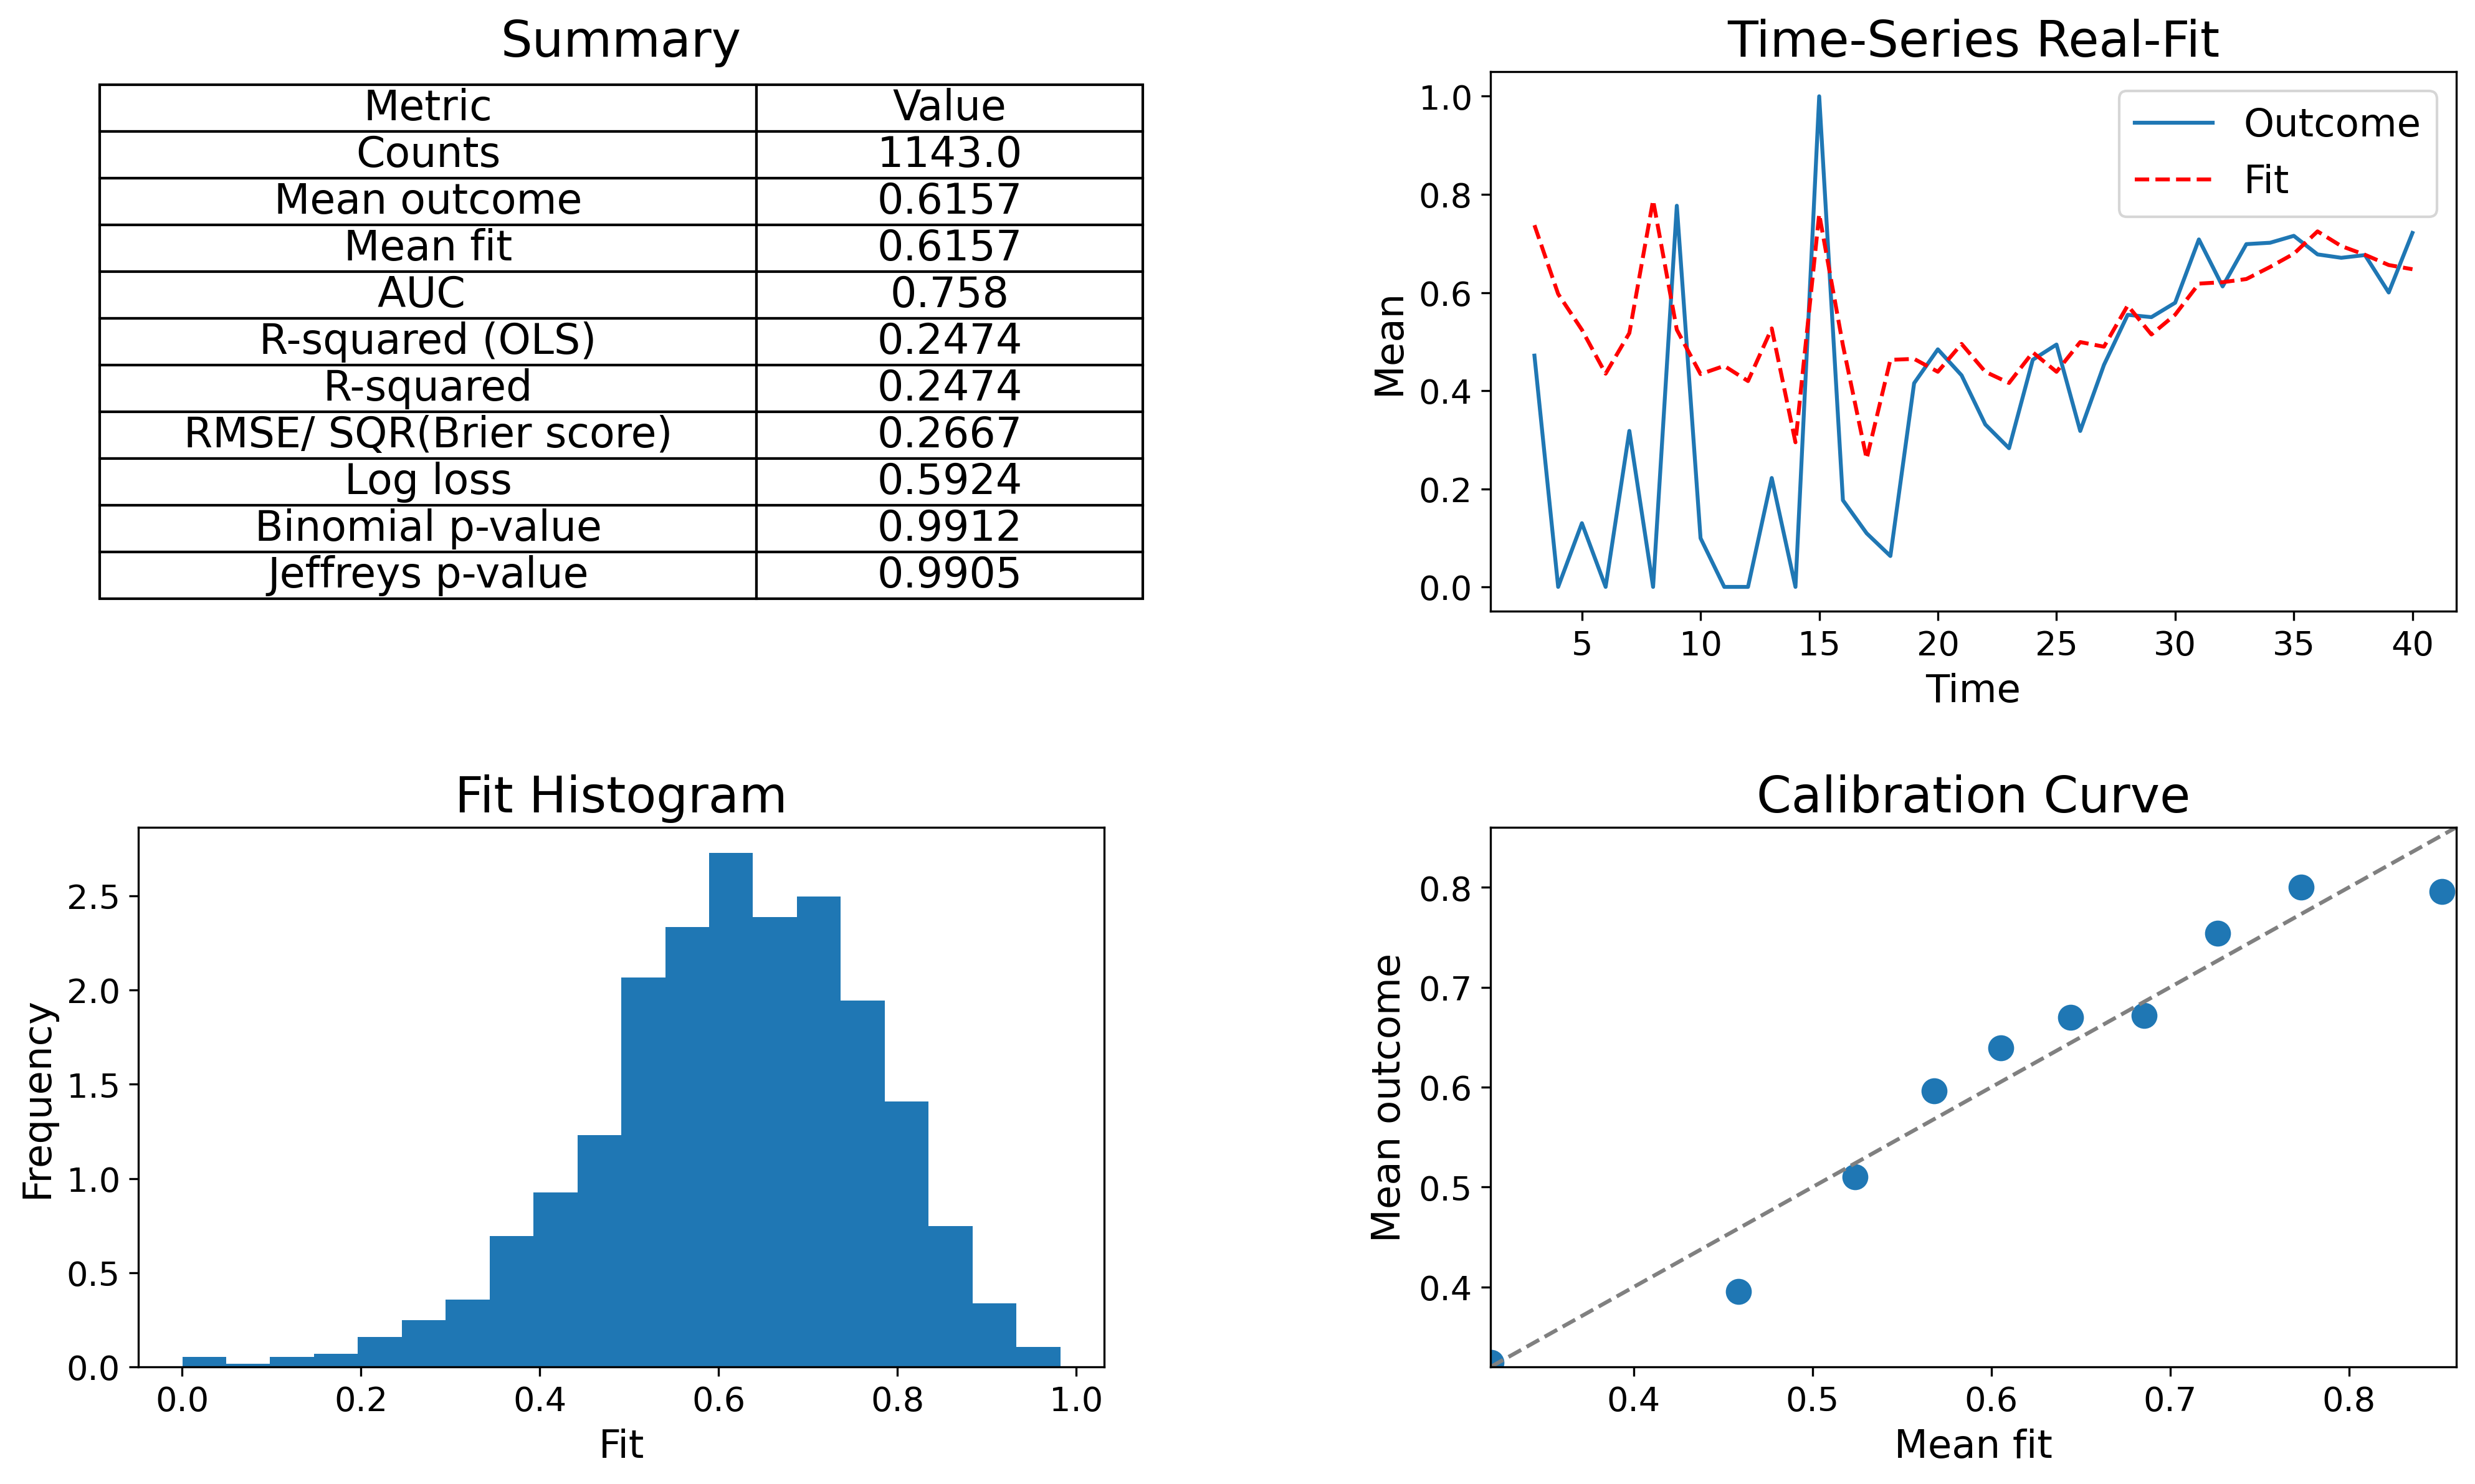

In [40]:
LGD_train = pd.DataFrame(model_ols_train.predict(data_train), columns = ['lgd_time_fit']) 
LGD_train = pd.concat([data_train[['lgd_time','time']], LGD_train], axis=1).dropna()  
LGD_train.loc[LGD_train['lgd_time_fit'] <= 0, 'lgd_time_fit'] = 0.0001  
LGD_train.loc[LGD_train['lgd_time_fit'] >= 1, 'lgd_time_fit'] = 0.9999 

validation(LGD_train.lgd_time_fit, LGD_train.lgd_time, LGD_train.time, continuous=True) 


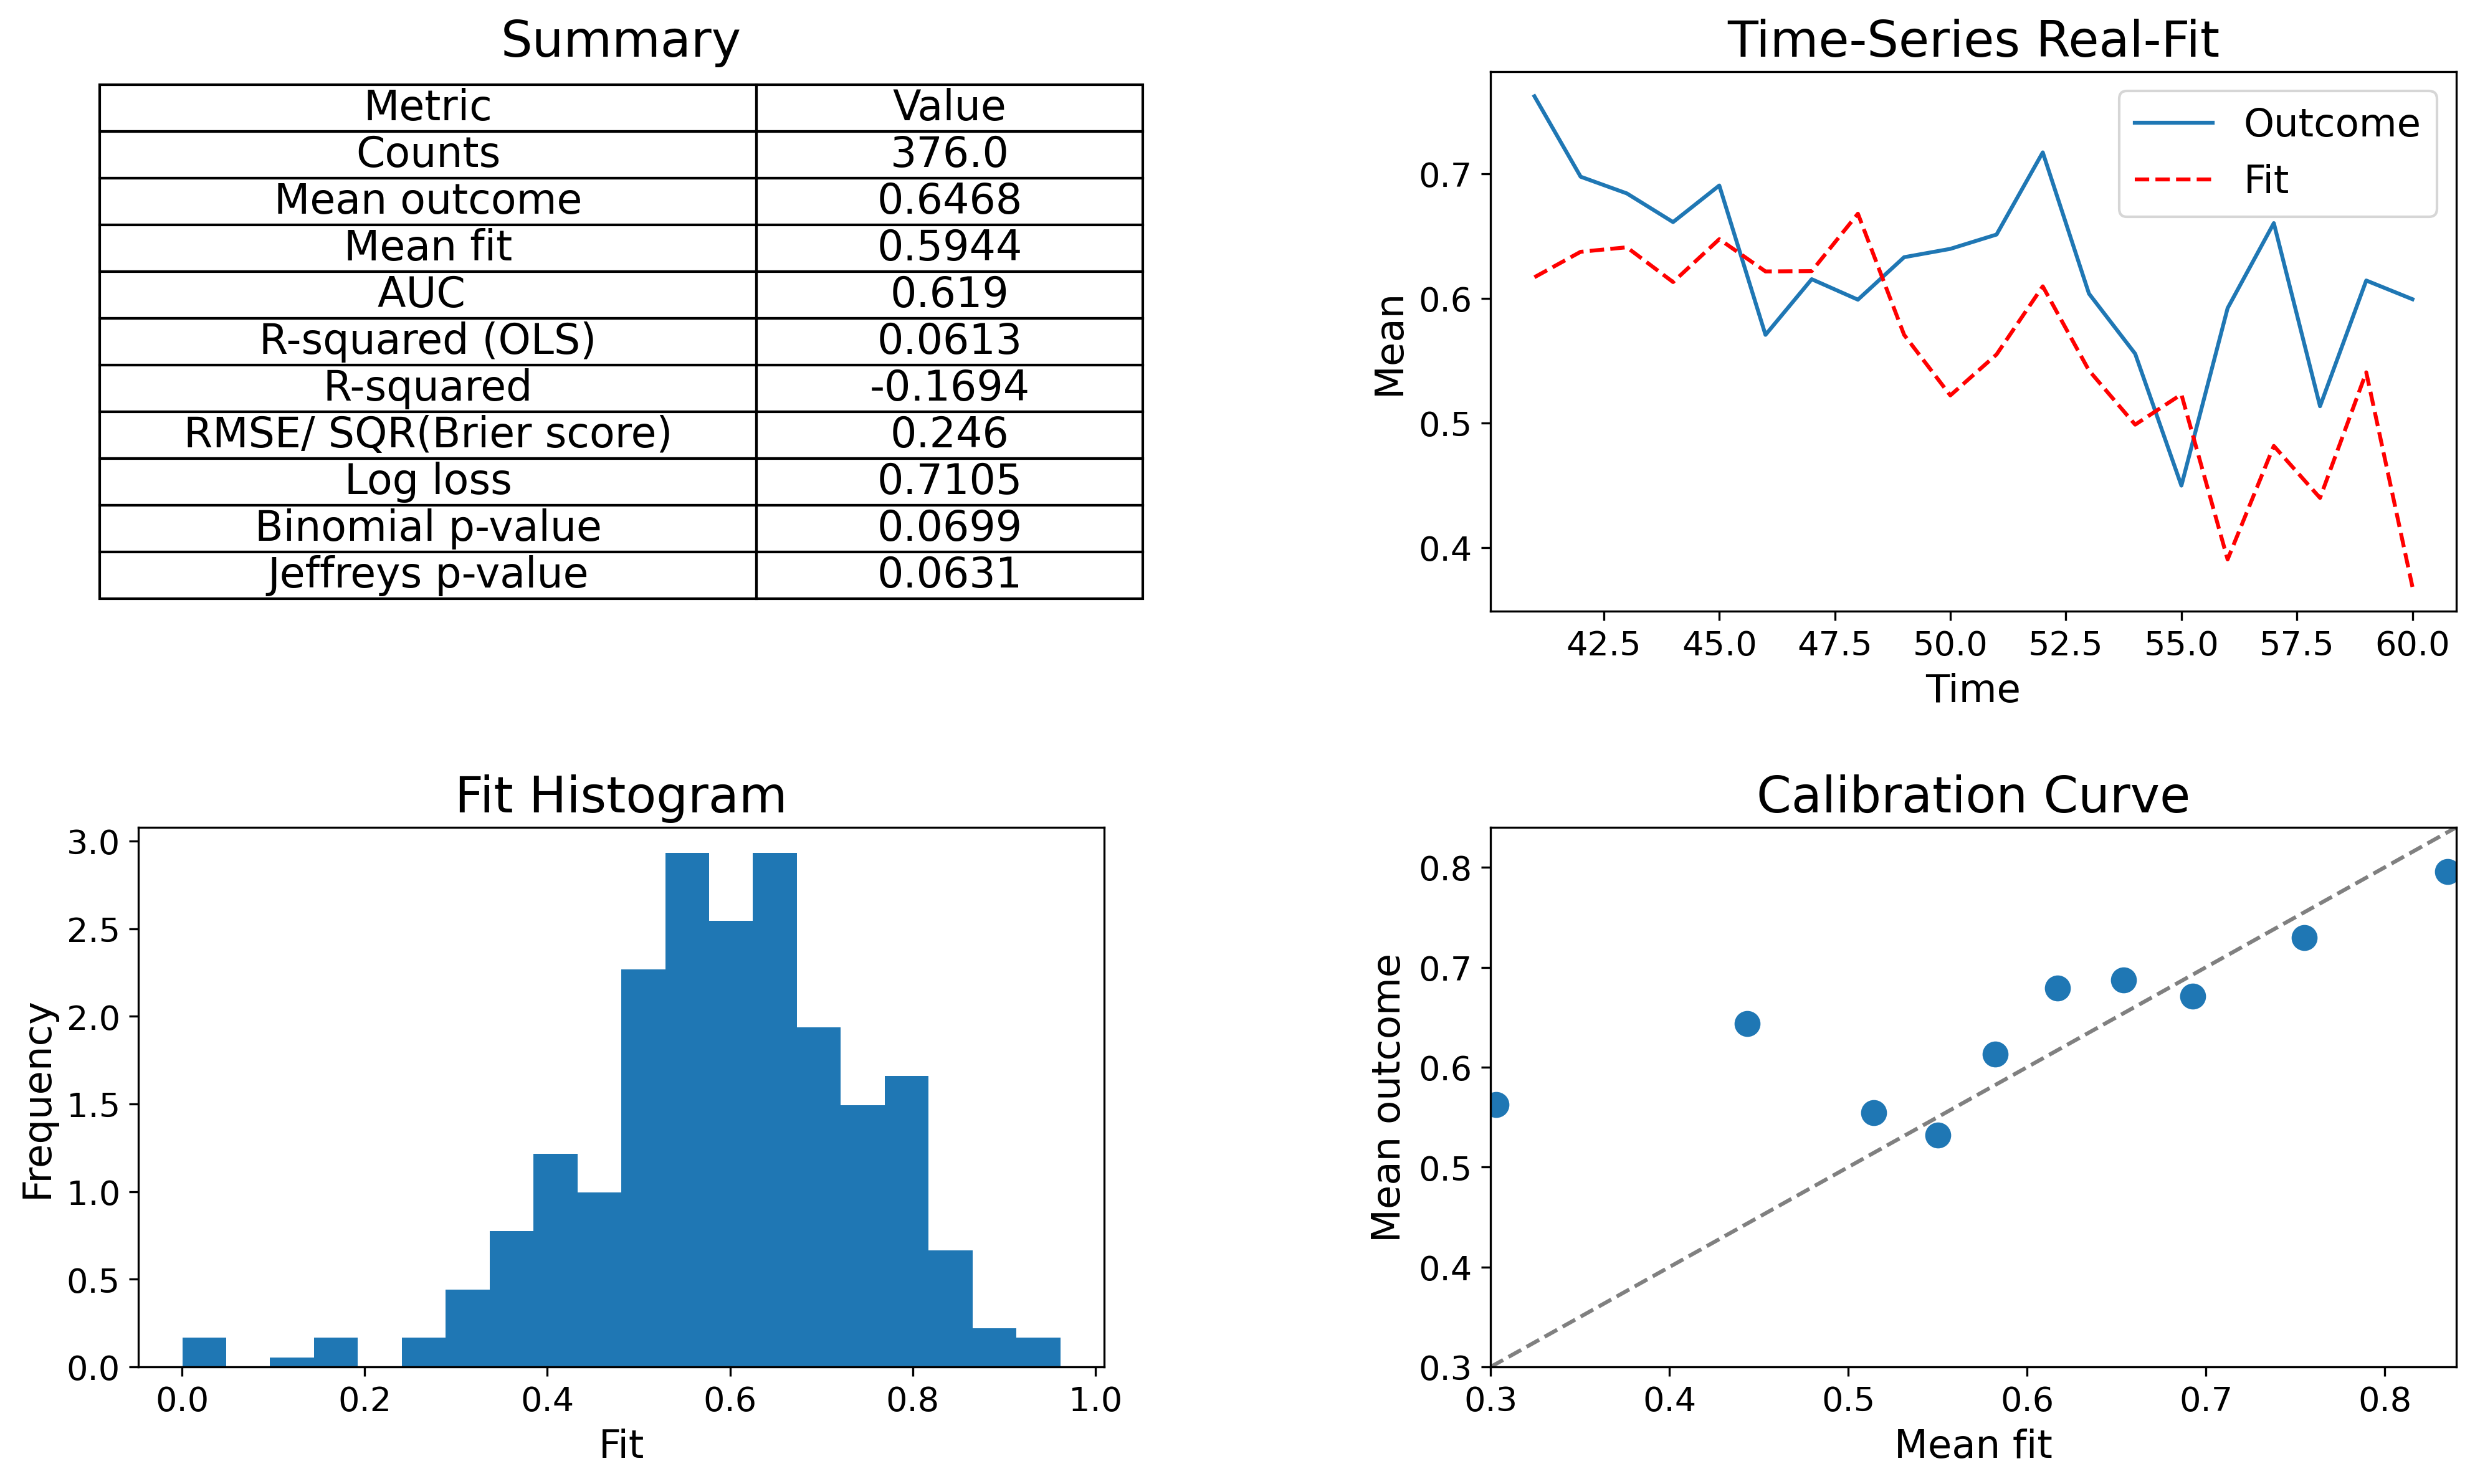

In [41]:
LGD_test = pd.DataFrame(model_ols_train.predict(data_test), columns = ['lgd_time_predict']) 
LGD_test = pd.concat([data_test[['lgd_time','time']], LGD_test], axis=1).dropna() 
LGD_test.loc[LGD_test['lgd_time_predict'] <= 0, 'lgd_time_predict'] = 0.0001  
LGD_test.loc[LGD_test['lgd_time_predict'] >= 1, 'lgd_time_predict'] = 0.9999 
 
validation(LGD_test.lgd_time_predict, LGD_test.lgd_time, LGD_test.time, continuous=True) 